In [72]:
import math as m
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import CoolProp.CoolProp as cp
import scipy.signal as signal
import tqdm

In [73]:
#in order for this to work, you need to import the data from the drive link into a folder in the same directory as this notebook, and name it "data/datalmao.txt"
#https://drive.google.com/file/d/1Vy08j-c-4Yad6g7GBfpu6iENSLCormvA/view?usp=sharing
#load data
time_strings = np.loadtxt(
    "data/datalmao.txt",
    delimiter=",",
    skiprows=1,
    usecols=(0,),
    dtype=str
)
time_raw = np.char.strip(time_strings, '"')
time_only = np.char.partition(time_raw, " ")[..., 2]

time_dt = np.array(
    [dt.datetime.strptime(s, "%m/%d/%y %H:%M:%S") for s in time_raw]
)
time = np.array(
    [(t - time_dt[0]).total_seconds() for t in time_dt],
    dtype=int
)

chA, chB = np.loadtxt(
    "data/datalmao.txt",
    delimiter=",",
    skiprows=1,
    usecols=(1, 2),
    unpack=True
)
## PTA is the outlet of the valve, PTB is the inlet.
ptA = 250 * chA - 125
ptB = 250 * chB - 125
mask = time <= 1500
ptAT = ptA - ptA[mask].mean()
ptBT = ptB - ptB[mask].mean()
time_only = np.char.partition(time_raw, " ")[..., 2]

time_dt = np.array(
    [dt.datetime.strptime(s, "%m/%d/%y %H:%M:%S") for s in time_raw]
)
time = np.array(
    [(t - time_dt[0]).total_seconds() for t in time_dt],
    dtype=int
)

chA, chB = np.loadtxt(
    "data/datalmao.txt",
    delimiter=",",
    skiprows=1,
    usecols=(1, 2),
    unpack=True
)
## PTA is the outlet of the valve, PTB is the inlet.
ptA = 250 * chA - 125
ptB = 250 * chB - 125
mask = time <= 1500
ptAT = ptA - ptA[mask].mean()
ptBT = ptB - ptB[mask].mean()


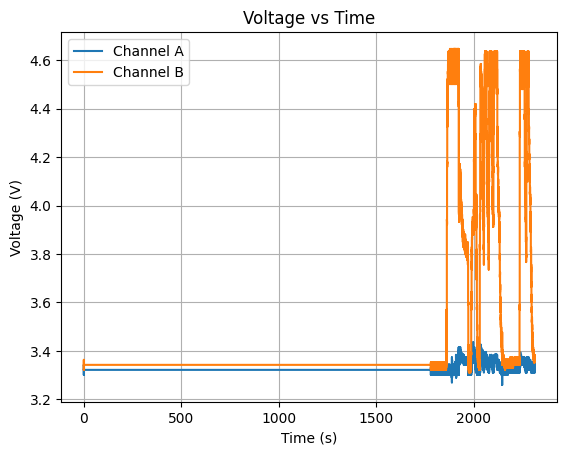

In [74]:
# raw voltage
plt.plot(time, chA, label="Channel A")
plt.plot(time, chB, label="Channel B")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Voltage vs Time")
plt.legend()
plt.grid()
plt.show()


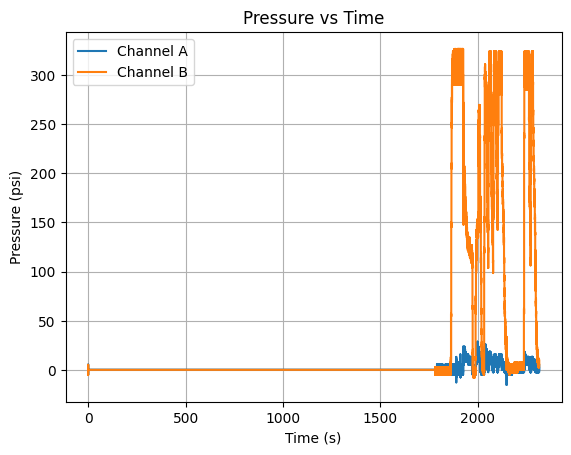

In [75]:
#raw pressure
plt.plot(time, ptAT, label="Channel A")
plt.plot(time, ptBT, label="Channel B")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (psi)")
plt.title("Pressure vs Time")
plt.legend()
plt.grid()
plt.show()


Estimated sampling rate: 1441.32 Hz
Top noise frequencies for Channel A:
  0.000 Hz, amplitude 2.079e+04
  0.001 Hz, amplitude 1.769e+04
  0.001 Hz, amplitude 1.764e+04
  0.004 Hz, amplitude 1.310e+04
  0.006 Hz, amplitude 1.210e+04
Top noise frequencies for Channel B:
  0.001 Hz, amplitude 9.160e+05
  0.000 Hz, amplitude 3.486e+05
  0.006 Hz, amplitude 2.848e+05
  0.002 Hz, amplitude 2.664e+05
  0.003 Hz, amplitude 2.139e+05


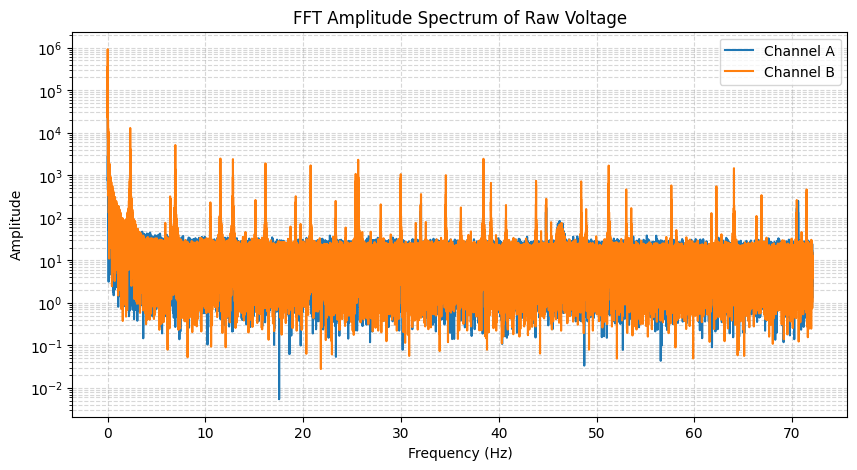

In [76]:
# FFT of raw voltage data to find strongest noise frequencies
N = len(chA)
duration = time[-1] - time[0]
fs = N / duration if duration > 0 else 1.0
signalA = chA - np.mean(chA)
signalB = chB - np.mean(chB)
fftA = np.fft.rfft(signalA)
fftB = np.fft.rfft(signalB)
freqs = np.fft.rfftfreq(N, d=1 / fs)
ampA = np.abs(fftA)
ampB = np.abs(fftB)
topA = np.argsort(ampA[1:])[::-1][:5] + 1
topB = np.argsort(ampB[1:])[::-1][:5] + 1
print(f"Estimated sampling rate: {fs:.2f} Hz")
print("Top noise frequencies for Channel A:")
for idx in topA:
    print(f"  {freqs[idx]:.3f} Hz, amplitude {ampA[idx]:.3e}")
print("Top noise frequencies for Channel B:")
for idx in topB:
    print(f"  {freqs[idx]:.3f} Hz, amplitude {ampB[idx]:.3e}")
plt.figure(figsize=(10, 5))
max_plot_freq = int(len(freqs) * 0.1)
plt.semilogy(freqs[1:max_plot_freq], ampA[1:max_plot_freq], label="Channel A")
plt.semilogy(freqs[1:max_plot_freq], ampB[1:max_plot_freq], label="Channel B")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT Amplitude Spectrum of Raw Voltage")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

C:\Users\gosup\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


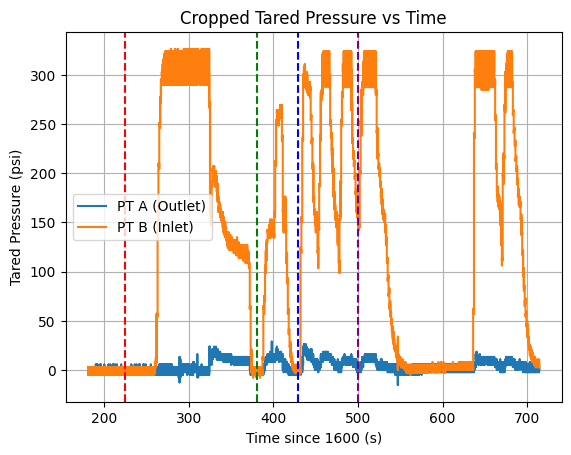

In [77]:
post1600 = time > 1600

timeCrop = time[post1600] - 1600
chACrop = chA[post1600]
chBCrop = chB[post1600]
ptACrop = ptA[post1600]
ptBCrop = ptB[post1600]
ptATCrop = ptAT[post1600]
ptBTCrop = ptBT[post1600]
timeDtCrop = time_dt[post1600]
timeOnlyCrop = time_only[post1600]
timeRawCrop = time_raw[post1600]
timeStringsCrop = time_strings[post1600]

plt.plot(timeCrop, ptATCrop, label="PT A (Outlet)")
plt.plot(timeCrop, ptBTCrop, label="PT B (Inlet)")
plt.xlabel("Time since 1600 (s)")
plt.ylabel("Tared Pressure (psi)")
plt.title("Cropped Tared Pressure vs Time")
plt.legend()
plt.grid()
plt.axvline(x=225, color="red", linestyle="--", label="Steady State")
plt.axvline(x=380, color="green", linestyle="--", label="Valve Close")
plt.axvline(x=429, color="blue", linestyle="--", label="2nd ROI Begin")
plt.axvline(x=500, color="purple", linestyle="--", label="2nd ROI End")
plt.show()

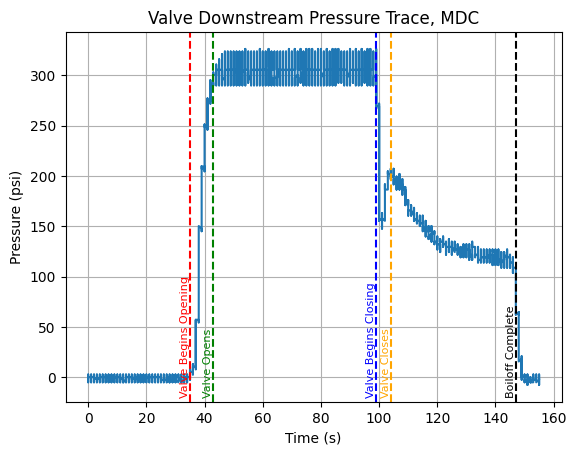

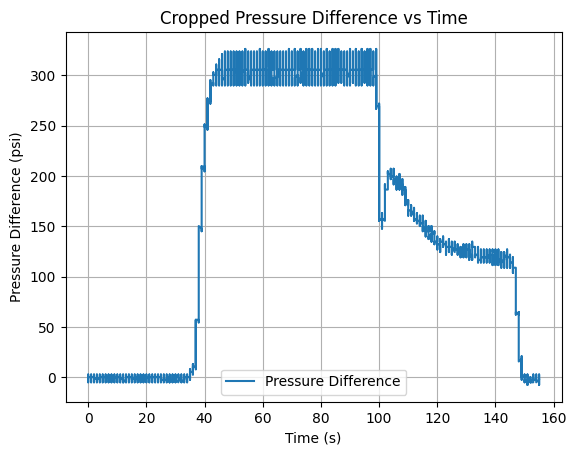

C:\Users\gosup\AppData\Local\Temp\ipykernel_12324\3950343317.py:60: RuntimeWarning: invalid value encountered in sqrt
  mdot = orifCdA * np.sqrt(2*rhoLn2*((ptBTCrop2-valveDrop)*6894.76))
100%|██████████| 975001/975001 [09:42<00:00, 1672.43it/s]  


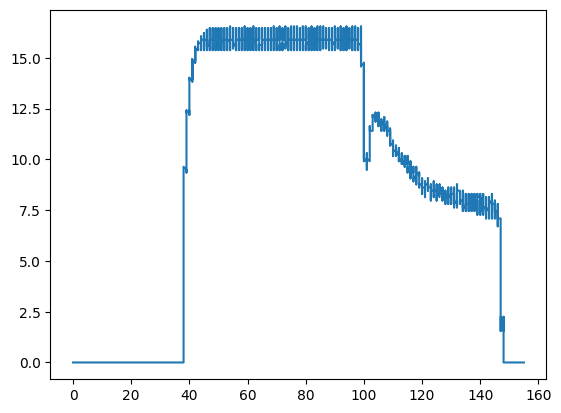

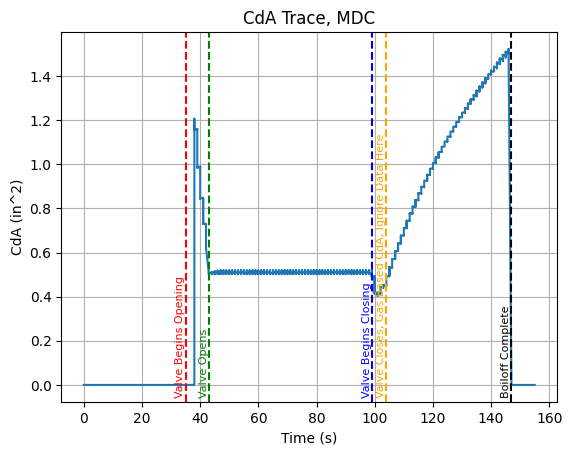

In [78]:
post225380 = (timeCrop >= 225) & (timeCrop <= 380)
timeCrop2 = timeCrop[post225380] - timeCrop[post225380][0]
ptATCrop2 = ptATCrop[post225380]
ptBTCrop2 = ptBTCrop[post225380]
plt.figure()
plt.plot(timeCrop2, ptBTCrop2, label="Outlet Pressure")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (psi)")
plt.title("Valve Downstream Pressure Trace, MDC")
plt.grid()

events = [
    (35,  "red", "Valve Begins Opening"),
    (43,  "green", "Valve Opens"),
    (99,  "blue", "Valve Begins Closing"),
    (104, "orange", "Valve Closes"),
    (147, "black", "Boiloff Complete"),
]

ax = plt.gca()
for xval, color, label in events:
    plt.axvline(xval, color=color, linestyle="--", label=label)
    ax.text(
        xval - 3.5, 0.01, label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="bottom",
        ha="left",
        color=color,
        fontsize=8,
    )

plt.show()
pressupDur = np.count_nonzero((timeCrop2 >= 35) & (timeCrop2 <= 43))
pressdownDur = np.count_nonzero((timeCrop2 >= 104) & (timeCrop2 < 147))
upQual = np.linspace(1, 0, pressupDur)
downQual = np.linspace(0, 1, pressdownDur)

# find CdA
dP = ptBTCrop2 - 0
plt.figure()
plt.plot(timeCrop2, dP, label="Pressure Difference")
plt.xlabel("Time (s)")
plt.ylabel("Pressure Difference (psi)")
plt.title("Cropped Pressure Difference vs Time")
plt.legend()
plt.grid()
plt.show()

rhoLn2 = cp.PropsSI("D", "P", 101325, "Q", 0, "N2")
dPPa = dP * 6894.757293168
dPPa = np.nan_to_num(dPPa, nan=0.0, posinf=0.0, neginf=0.0)
#need rough mdot approx, we knew this would be shitty anyways
# mdot = 1.0  # kg/s, temp
valveDrop = 60 #psi
orifDia = 1 * 0.0254 # in -> m
orifArea = np.pi * (orifDia/2)**2 # m^2
orifCd = 0.6 # sharp edge reducer
orifCdA = orifCd * orifArea # m^2, 1" -> .25" orifice, Cd ~ 0.6
mdot = orifCdA * np.sqrt(2*rhoLn2*((ptBTCrop2-valveDrop)*6894.76))
mdot = np.nan_to_num(mdot, nan=0.0, posinf=0.0, neginf=0.0)
plt.plot(timeCrop2, mdot, label="Estimated Mass Flow Rate (kg/s)")
upIndex = 0
downIndex = 0
CdA = np.float64(np.zeros_like(timeCrop2))
rho = np.float64(np.zeros_like(timeCrop2))
for i in tqdm.tqdm(range(len(timeCrop2))):
    if timeCrop2[i] < 35:
        qual = 1.0
        try:
            rho[i] = cp.PropsSI("D", "P", ptBTCrop2[i]*6894.76+101325, "Q", qual, "N2")
        except:
            rho[i] = cp.PropsSI("D","P", 101325, "Q", qual, "N2")
    elif timeCrop2[i] >= 35 and timeCrop2[i] < 43:
        try:
            rho[i] = cp.PropsSI("D","P", ptBTCrop2[i]*6894.76+101325, "Q",upQual[upIndex] ,"N2")
            upIndex += 1
        except:
            rho[i] = cp.PropsSI("D","P", ptBTCrop2[i]*6894.76+101325, "Q", 1.0, "N2")
    elif timeCrop2[i] >= 43 and timeCrop2[i] < 104:
        try:
            rho[i] = cp.PropsSI("D","P", ptBTCrop2[i]*6894.76+101325, "Q", 0, "N2")
        except:
            rho[i] = cp.PropsSI("D","P", 101325, "Q", 0, "N2")
    elif timeCrop2[i] >= 104 and timeCrop2[i] < 147:
        try:
            rho[i] = cp.PropsSI("D","P", ptBTCrop2[i]*6894.76+101325, "Q", downQual[downIndex], "N2")
            downIndex += 1
        except:
            rho[i] = cp.PropsSI("D","P", ptBTCrop2[i]*6894.76+101325, "Q", 1, "N2")
    if np.isinf(rho[i]):
        rho[i] = rhoLn2
    if rho[i] >= 1.0:
        CdAInst = mdot[i]/np.sqrt(2*rho[i]*np.abs(dPPa[i]))
        CdA[i] = CdAInst
    else:
        CdA[i] = 0.0
CdAIn = CdA * 1550 # m^2 -> in^2
plt.figure()
plt.plot(timeCrop2, CdAIn, label="CdA")
plt.xlabel("Time (s)")
plt.ylabel("CdA (in^2)")
plt.title("CdA Trace, MDC")
plt.grid()
events = [
    (35,  "red", "Valve Begins Opening"),
    (43,  "green", "Valve Opens"),
    (99,  "blue", "Valve Begins Closing"),
    (104, "orange", "Valve Closes, Gas Based CdA, Ignore Data Here"),
    (147, "black", "Boiloff Complete"),
]

ax = plt.gca()
for xval, color, label in events:
    plt.axvline(xval, color=color, linestyle="--", label=label)
    ax.text(
        xval - 3.5, 0.01, label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="bottom",
        ha="left",
        color=color,
        fontsize=8,
    )

plt.show()


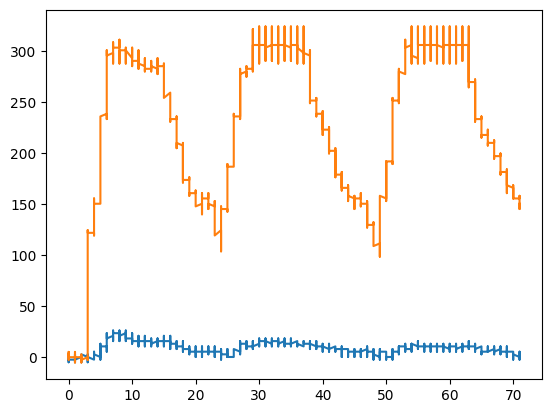

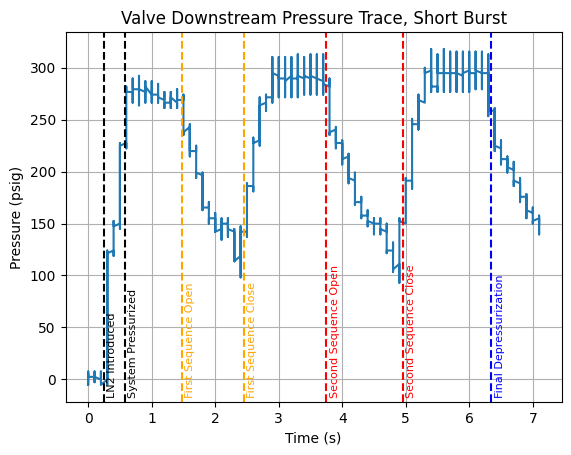

C:\Users\gosup\AppData\Local\Temp\ipykernel_12324\2187965701.py:51: RuntimeWarning: invalid value encountered in sqrt
  mdot = orifCdA * np.sqrt(2*rhoLn2*((ptBTCrop3-valveDrop)*6894.76))
100%|██████████| 450001/450001 [00:00<00:00, 747353.39it/s]


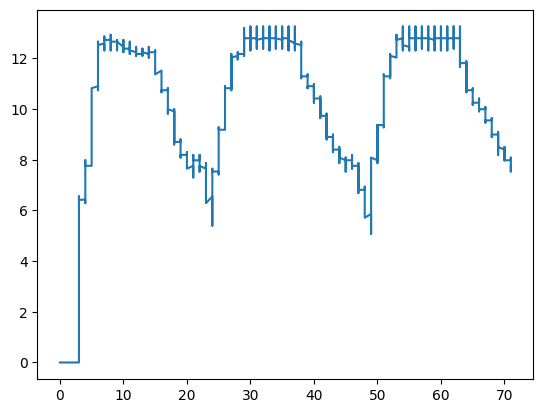

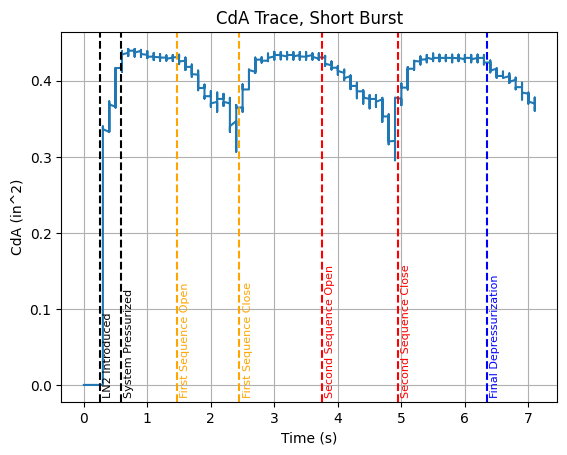

In [80]:
post429500 = (timeCrop >= 429) & (timeCrop <= 500)
timeCrop3 = timeCrop[post429500] - timeCrop[post429500][0]
ptATCrop3 = ptATCrop[post429500]
ptBTCrop3 = ptBTCrop[post429500]
# find CdA
dP = ptBTCrop3 - ptATCrop3
plt.plot(timeCrop3, ptATCrop3, label="PT A (Outlet)")
plt.plot(timeCrop3, ptBTCrop3, label="PT B (Inlet)")
plt.figure()
plt.plot(timeCrop3/10, dP, label="Valve Downstream Pressrue")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (psig)")
plt.title("Valve Downstream Pressure Trace, Short Burst")
plt.grid()

events = [
    (0.25, "black",  "LN2 Introduced"),
    (0.58, "black",  "System Pressurized"),
    (1.47, "orange", "First Sequence Open"),
    (2.45, "orange", "First Sequence Close"),
    (3.75, "red",    "Second Sequence Open"),
    (4.95, "red",    "Second Sequence Close"),
    (6.35, "blue",   "Final Depressurization"),
]

ax = plt.gca()
for xval, color, label in events:
    plt.axvline(xval, color=color, linestyle="--", label=label)
    ax.text(
        xval + 0.05, 0.01, label,
        transform=ax.get_xaxis_transform(),  # x in data coords, y in axes coords (0-1)
        rotation=90,
        va="bottom",
        ha="left",
        color=color,
        fontsize=8,
    )

plt.show()

rhoLn2 = cp.PropsSI("D", "P", (350+14.7)*6894.76, "Q", 0, "N2")
dPPa = dP * 6894.757293168
dPPa = np.nan_to_num(dPPa, nan=0.0, posinf=0.0, neginf=0.0)
#need rough mdot approx, we knew this would be shitty anyways
# mdot = 1.0  # kg/s, temp
valveDrop = 60 #psi
orifDia = 1 * 0.0254 # in -> m
orifArea = np.pi * (orifDia/2)**2 # m^2
orifCd = 0.6 # sharp edge reducer
orifCdA = orifCd * orifArea # m^2, 1" -> .25" orifice, Cd ~ 0.6
mdot = orifCdA * np.sqrt(2*rhoLn2*((ptBTCrop3-valveDrop)*6894.76))
mdot = np.nan_to_num(mdot, nan=0.0, posinf=0.0, neginf=0.0)
plt.plot(timeCrop3, mdot, label="Estimated Mass Flow Rate (kg/s)")
upIndex = 0
downIndex = 0
CdA2 = np.float64(np.zeros_like(timeCrop3))
rho = np.float64(np.zeros_like(timeCrop3))
for i in tqdm.tqdm(range(len(timeCrop3))):
    CdAInst = mdot[i]/np.sqrt(2*rhoLn2*np.abs(dPPa[i]))
    CdA2[i] = CdAInst
CdAIn2 = CdA2 * 1550 # m^2 -> in^2
plt.figure()
plt.plot(timeCrop3/10, CdAIn2, label="CdA")
plt.xlabel("Time (s)")
plt.ylabel("CdA (in^2)")
plt.title("CdA Trace, Short Burst")
plt.grid()
events = [
    (0.25, "black",  "LN2 Introduced"),
    (0.58, "black",  "System Pressurized"),
    (1.47, "orange", "First Sequence Open"),
    (2.45, "orange", "First Sequence Close"),
    (3.75, "red",    "Second Sequence Open"),
    (4.95, "red",    "Second Sequence Close"),
    (6.35, "blue",   "Final Depressurization"),
]

ax = plt.gca()
for xval, color, label in events:
    plt.axvline(xval, color=color, linestyle="--", label=label)
    ax.text(
        xval + 0.05, 0.01, label,
        transform=ax.get_xaxis_transform(),  # x in data coords, y in axes coords (0-1)
        rotation=90,
        va="bottom",
        ha="left",
        color=color,
        fontsize=8,
    )

plt.show()
